In [4]:
import pandas as pd, numpy as np, glob, os, shutil

chk=pd.read_csv('X_features/_health_check.csv')
chk['bid']=chk['bid'].apply(lambda x:f'{int(x):03d}')

TARGET=28
np.random.seed(42)

chk_use=chk.copy()   # 若20DOD不进测试:chk[chk['DOD']!=20]
test_bids=[]
for dod,grp in chk_use.groupby('DOD'):
    quota=max(1, round(TARGET*len(grp)/len(chk_use)))
    quota=min(quota, len(grp)-1)          # 保证训练也有该工况
    quota=max(quota, 0)
    if quota<=0: continue
    # 先按温度排序打散,再等间隔取,保证温度覆盖
    g=grp.sort_values('Temp').reset_index(drop=True)
    idx=np.linspace(0, len(g)-1, quota).round().astype(int)
    idx=np.unique(idx)
    test_bids+=g.loc[idx,'bid'].tolist()

test_bids=sorted(set(test_bids))[:TARGET]
print(f"测试集 {len(test_bids)} 块")
tinfo=chk[chk['bid'].isin(test_bids)]
print("DOD分布:", tinfo['DOD'].value_counts().sort_index().to_dict())
print("温度分布:", tinfo['Temp'].value_counts().sort_index().to_dict())
print("测试电池:", test_bids)

# 物理隔离(先清空重分)
for d in ['X_test','X_train']:
    if os.path.exists(d): shutil.rmtree(d)
    os.makedirs(d)
for f in glob.glob('X_features/X_*.csv')+glob.glob('X_features_20DOD/X_*.csv'):
    bid=os.path.basename(f).replace('X_','').replace('.csv','')
    dst='X_test' if bid in test_bids else 'X_train'
    shutil.copy(f, f'{dst}/X_{bid}.csv')
print(f"\n训练集: {len(glob.glob('X_train/X_*.csv'))}块")
print(f"测试集: {len(glob.glob('X_test/X_*.csv'))}块 (不进训练)")

测试集 28 块
DOD分布: {20: 11, 40: 5, 60: 8, 80: 1, 100: 3}
温度分布: {15: 6, 25: 7, 35: 10, 45: 5}
测试电池: ['021', '025', '050', '061', '086', '099', '107', '123', '155', '163', '164', '176', '178', '183', '206', '237', '247', '257', '258', '405', '414', '416', '421', '450', '455', '475', '490', '594']

训练集: 244块
测试集: 28块 (不进训练)


In [7]:
import pandas as pd, numpy as np, glob, os
import torch, torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ==================== 可调参数区(只改这里)====================
CFG = {
    # ---- 训练过程 ----
    'epochs': 60,
    'lr': 1e-3,
    'batch_size': 256,
    'weight_decay': 1e-5,     # L2正则,过拟合就加大(如1e-4)
    'patience': 6,            # 早停:验证连续这么多轮不提升就停
    'lr_factor': 0.5,         # 学习率衰减倍数
    'lr_patience': 3,         # 几轮不提升就衰减lr
    # ---- 防过拟合 ----
    'dropout': 0.3,           # 过拟合就加大(如0.5)
    # ---- 模型结构 ----
    'conv_channels': [32, 64],    # 卷积通道;加一个数=加一层,如[32,64,128]
    'kernel_size': 3,             # 卷积核;可试5
    'pool_size': 4,               # 池化输出长度
    'pool_type': 'avg',           # 'avg' 或 'max'
    'fc_hidden': [128, 32],       # 全连接隐层
    # ---- 数据 ----
    'exclude_20DOD': False,       # True=训练时排除20DOD
    'val_frac': 0.15,             # 从训练集分多少块做验证
    'loss': 'mse',                # 'mse' / 'mae' / 'huber'
    'seed': 42,
    'y_lo': 50.0, 'y_hi': 105.0,  # SOH归一化范围
}
# ============================================================

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)
torch.manual_seed(CFG['seed']); np.random.seed(CFG['seed'])

FEAT_COLS=[f'Q_{i}' for i in range(16)]+[f'dQ_{i}' for i in range(16)]+\
          [f'IC_{i}' for i in range(16)]+['h_peak','dVpeak']

# ---------- 1. 读训练集,按块划验证 ----------
files=sorted(glob.glob('X_train/X_*.csv'))
if CFG['exclude_20DOD']:
    meta=pd.read_csv('usable_batteries.csv'); meta['bid']=meta['bid'].apply(lambda x:f'{int(x):03d}')
    dod20=set(meta[meta['DOD']==20]['bid'])
    files=[f for f in files if os.path.basename(f).replace('X_','').replace('.csv','') not in dod20]
    print(f"排除20DOD后 {len(files)}块")

val_files=set(np.random.choice(files, max(1,int(len(files)*CFG['val_frac'])), replace=False))
def load(fl):
    Xs,ys=[],[]
    for f in fl:
        df=pd.read_csv(f); Xs.append(df[FEAT_COLS].values); ys.append(df['SOH'].values)
    return np.vstack(Xs), np.concatenate(ys)
X_tr,y_tr=load([f for f in files if f not in val_files])
X_va,y_va=load(list(val_files))
print(f"训练 {X_tr.shape} ({len(files)-len(val_files)}块), 验证 {X_va.shape} ({len(val_files)}块)")

# ---------- 2. 归一化(只从训练算)----------
x_min=X_tr.min(0); x_max=X_tr.max(0); x_rng=np.where(x_max-x_min==0,1,x_max-x_min)
X_tr_n=(X_tr-x_min)/x_rng; X_va_n=(X_va-x_min)/x_rng
Y_LO,Y_HI=CFG['y_lo'],CFG['y_hi']
y_tr_n=(y_tr-Y_LO)/(Y_HI-Y_LO); y_va_n=(y_va-Y_LO)/(Y_HI-Y_LO)

def to_cnn(X): return X[:,:48].reshape(-1,3,16), X[:,48:]
seq_tr,scal_tr=to_cnn(X_tr_n); seq_va,scal_va=to_cnn(X_va_n)
def mkdl(seq,scal,y,bs,sh):
    ds=TensorDataset(torch.tensor(seq,dtype=torch.float32),
                     torch.tensor(scal,dtype=torch.float32),
                     torch.tensor(y,dtype=torch.float32))
    return DataLoader(ds,batch_size=bs,shuffle=sh)
tr_dl=mkdl(seq_tr,scal_tr,y_tr_n,CFG['batch_size'],True)
va_dl=mkdl(seq_va,scal_va,y_va_n,512,False)

# ---------- 3. 参数化模型 ----------
class SOHNet(nn.Module):
    def __init__(self,cfg):
        super().__init__()
        layers=[]; in_c=3; k=cfg['kernel_size']
        for out_c in cfg['conv_channels']:
            layers+=[nn.Conv1d(in_c,out_c,k,padding=k//2),nn.ReLU(),nn.BatchNorm1d(out_c)]
            in_c=out_c
        pool=nn.AdaptiveMaxPool1d if cfg['pool_type']=='max' else nn.AdaptiveAvgPool1d
        layers.append(pool(cfg['pool_size']))
        self.conv=nn.Sequential(*layers)
        flat=in_c*cfg['pool_size']+2
        fc=[]; prev=flat
        for h in cfg['fc_hidden']:
            fc+=[nn.Linear(prev,h),nn.ReLU(),nn.Dropout(cfg['dropout'])]; prev=h
        fc.append(nn.Linear(prev,1))
        self.head=nn.Sequential(*fc)
    def forward(self,seq,scal):
        z=self.conv(seq).flatten(1); z=torch.cat([z,scal],1)
        return self.head(z).squeeze(1)

model=SOHNet(CFG).to(device)
n_param=sum(p.numel() for p in model.parameters())
print(f"模型参数量: {n_param}")

opt=torch.optim.Adam(model.parameters(),lr=CFG['lr'],weight_decay=CFG['weight_decay'])
lossf={'mse':nn.MSELoss(),'mae':nn.L1Loss(),'huber':nn.HuberLoss()}[CFG['loss']]
sched=torch.optim.lr_scheduler.ReduceLROnPlateau(opt,mode='max',
        factor=CFG['lr_factor'],patience=CFG['lr_patience'])

def evaluate(dl):
    model.eval(); ps,ts=[],[]
    with torch.no_grad():
        for s,sc,y in dl:
            ps.append(model(s.to(device),sc.to(device)).cpu().numpy()); ts.append(y.numpy())
    p=np.concatenate(ps)*(Y_HI-Y_LO)+Y_LO; t=np.concatenate(ts)*(Y_HI-Y_LO)+Y_LO
    rmse=np.sqrt(((p-t)**2).mean()); mae=np.abs(p-t).mean()
    r2=1-((p-t)**2).sum()/((t-t.mean())**2).sum()
    return rmse,mae,r2

# ---------- 4. 训练(早停+lr衰减)----------
best_r2=-9; best_state=None; wait=0
for ep in range(1,CFG['epochs']+1):
    model.train(); tot=0
    for s,sc,y in tr_dl:
        opt.zero_grad(); loss=lossf(model(s.to(device),sc.to(device)),y.to(device))
        loss.backward(); opt.step(); tot+=loss.item()*len(y)
    rmse,mae,r2=evaluate(va_dl); sched.step(r2)
    if r2>best_r2:
        best_r2=r2; best_state={k:v.cpu().clone() for k,v in model.state_dict().items()}; wait=0; star="  ← best"
    else:
        wait+=1; star=""
    if ep%2==0 or ep==1 or star:
        print(f"ep{ep:2d} loss{tot/len(tr_dl.dataset):.5f}  VAL RMSE{rmse:.3f}% MAE{mae:.3f}% R²{r2:.4f}{star}")
    if wait>=CFG['patience']:
        print(f"早停于ep{ep}"); break

model.load_state_dict(best_state)
rmse,mae,r2=evaluate(va_dl)
print(f"\n★ 最佳模型 验证集: RMSE={rmse:.3f}%  MAE={mae:.3f}%  R²={r2:.4f}")
torch.save({'model':best_state,'x_min':x_min,'x_max':x_max,'cfg':CFG},'soh_cnn_best.pt')
print("saved soh_cnn_best.pt")

device: cpu
训练 (1700676, 50) (208块), 验证 (288755, 50) (36块)
模型参数量: 44033
ep 1 loss0.00445  VAL RMSE1.926% MAE1.434% R²0.9170  ← best
ep 2 loss0.00131  VAL RMSE2.148% MAE1.676% R²0.8967
ep 3 loss0.00118  VAL RMSE1.803% MAE1.282% R²0.9272  ← best
ep 4 loss0.00111  VAL RMSE2.835% MAE2.158% R²0.8201
ep 6 loss0.00107  VAL RMSE1.609% MAE1.170% R²0.9421  ← best
ep 8 loss0.00102  VAL RMSE1.808% MAE1.275% R²0.9269
ep10 loss0.00101  VAL RMSE1.753% MAE1.281% R²0.9312
ep11 loss0.00088  VAL RMSE1.599% MAE1.169% R²0.9428  ← best
ep12 loss0.00087  VAL RMSE1.814% MAE1.329% R²0.9263
ep13 loss0.00086  VAL RMSE1.520% MAE1.071% R²0.9483  ← best
ep14 loss0.00086  VAL RMSE1.551% MAE1.110% R²0.9461
ep16 loss0.00085  VAL RMSE1.652% MAE1.137% R²0.9389
ep18 loss0.00078  VAL RMSE1.513% MAE1.078% R²0.9488  ← best
ep20 loss0.00077  VAL RMSE1.540% MAE1.076% R²0.9469
ep21 loss0.00077  VAL RMSE1.510% MAE1.036% R²0.9490  ← best
ep22 loss0.00076  VAL RMSE1.497% MAE1.073% R²0.9498  ← best
ep24 loss0.00076  VAL RMSE1.551%

In [8]:
import glob, os, pandas as pd

os.makedirs('X_test_noleak', exist_ok=True)   # 只有特征,无SOH
os.makedirs('y_test_secret', exist_ok=True)   # 答案,单独锁起来

# 特征列(除SOH外全部)
sample=pd.read_csv(glob.glob('X_test/X_*.csv')[0])
FEAT=[c for c in sample.columns if c!='SOH']

for f in sorted(glob.glob('X_test/X_*.csv')):
    bid=os.path.basename(f).replace('X_','').replace('.csv','')
    df=pd.read_csv(f)
    df[FEAT].to_csv(f'X_test_noleak/X_{bid}.csv', index=False)      # 无答案
    df[['SOH']].to_csv(f'y_test_secret/y_{bid}.csv', index=False)   # 答案
print(f"已分离 {len(glob.glob('X_test_noleak/X_*.csv'))} 块")
print(f"  X_test_noleak/ : 只有50维特征,无SOH")
print(f"  y_test_secret/ : 只有SOH答案")
# 验证:无泄漏的X里确实没有SOH列
chk=pd.read_csv(glob.glob('X_test_noleak/X_*.csv')[0])
print(f"  确认: X_test_noleak的列里{'没有' if 'SOH' not in chk.columns else '⚠️还有'}SOH")

已分离 28 块
  X_test_noleak/ : 只有50维特征,无SOH
  y_test_secret/ : 只有SOH答案
  确认: X_test_noleak的列里没有SOH


In [9]:
import numpy as np, pandas as pd, glob, os, torch

# ---- 阶段1:只读无答案的X,模型预测(全程碰不到SOH)----
FEAT_COLS=[f'Q_{i}' for i in range(16)]+[f'dQ_{i}' for i in range(16)]+\
          [f'IC_{i}' for i in range(16)]+['h_peak','dVpeak']

preds={}   # 每块的预测结果
for f in sorted(glob.glob('X_test_noleak/X_*.csv')):
    bid=os.path.basename(f).replace('X_','').replace('.csv','')
    df=pd.read_csv(f)                          # 这里读进来的绝对没有SOH
    X=df[FEAT_COLS].values
    X_n=(X-x_min)/x_rng                         # 用训练集的min/max
    seq,scal=to_cnn(X_n)
    model.eval()
    with torch.no_grad():
        p=model(torch.tensor(seq,dtype=torch.float32).to(device),
                torch.tensor(scal,dtype=torch.float32).to(device)).cpu().numpy()
    p=p*(Y_HI-Y_LO)+Y_LO                        # 反归一化回SOH%
    preds[bid]=p
print(f"盲测完成:{len(preds)}块,预测阶段全程未接触任何真实SOH")

# ---- 阶段2:现在才调取答案,对比算指标 ----
all_p,all_t=[],[]
per_cell=[]
for bid,p in preds.items():
    y=pd.read_csv(f'y_test_secret/y_{bid}.csv')['SOH'].values   # 此刻才读答案
    all_p.append(p); all_t.append(y)
    rmse=np.sqrt(((p-y)**2).mean()); r2=1-((p-y)**2).sum()/((y-y.mean())**2).sum()
    per_cell.append({'bid':bid,'n':len(y),'RMSE':rmse,'R2':r2})
all_p=np.concatenate(all_p); all_t=np.concatenate(all_t)

# 整体指标
rmse=np.sqrt(((all_p-all_t)**2).mean()); mae=np.abs(all_p-all_t).mean()
r2=1-((all_p-all_t)**2).sum()/((all_t-all_t.mean())**2).sum()
print(f"\n★★ 测试集整体(28块,严格盲测): RMSE={rmse:.3f}%  MAE={mae:.3f}%  R²={r2:.4f}")

# 每块的表现(看哪些块好哪些差)
pc=pd.DataFrame(per_cell).sort_values('R2')
print(f"\n每块表现(最差5块):")
print(pc.head().to_string(index=False))
print(f"\n每块表现(最好5块):")
print(pc.tail().to_string(index=False))

盲测完成:28块,预测阶段全程未接触任何真实SOH

★★ 测试集整体(28块,严格盲测): RMSE=1.311%  MAE=0.937%  R²=0.9558

每块表现(最差5块):
bid    n     RMSE        R2
237 5493 2.108487 -2.035858
257 6647 3.361461  0.565318
416 3002 1.386287  0.574417
163 4309 2.642806  0.622760
475 2960 0.862132  0.733264

每块表现(最好5块):
bid     n     RMSE       R2
107  9223 1.261646 0.978170
061  4035 1.345546 0.979896
155 13454 0.501733 0.982043
594  8074 0.780274 0.982424
247  9351 0.684663 0.983442


In [10]:
import pandas as pd, numpy as np

# 看237的真实SOH和预测
bid='237'
y=pd.read_csv(f'y_test_secret/y_{bid}.csv')['SOH'].values
p=preds[bid]
print(f"237号:")
print(f"  真实SOH范围: {y.min():.2f}~{y.max():.2f} (跨度{y.max()-y.min():.2f})")
print(f"  预测SOH范围: {p.min():.2f}~{p.max():.2f}")
print(f"  真实SOH均值±std: {y.mean():.2f}±{y.std():.2f}")
print(f"  预测偏差(pred-true)均值: {(p-y).mean():.2f}")

# 关键:如果SOH跨度很小,R²天然低
print(f"\n  如果SOH跨度<3%,R²为负是正常的(分母太小,R²不适用)")

# 看237工况
try:
    meta=pd.read_csv('usable_batteries.csv'); meta['bid']=meta['bid'].apply(lambda x:f'{int(x):03d}')
    print(f"  237工况:", meta[meta['bid']=='237'][['Temp','SOC','DOD']].to_dict('records'))
except: pass

237号:
  真实SOH范围: 97.70~101.40 (跨度3.70)
  预测SOH范围: 88.22~101.83
  真实SOH均值±std: 98.32±1.21
  预测偏差(pred-true)均值: -1.07

  如果SOH跨度<3%,R²为负是正常的(分母太小,R²不适用)
  237工况: [{'Temp': 45, 'SOC': 50, 'DOD': 60}]


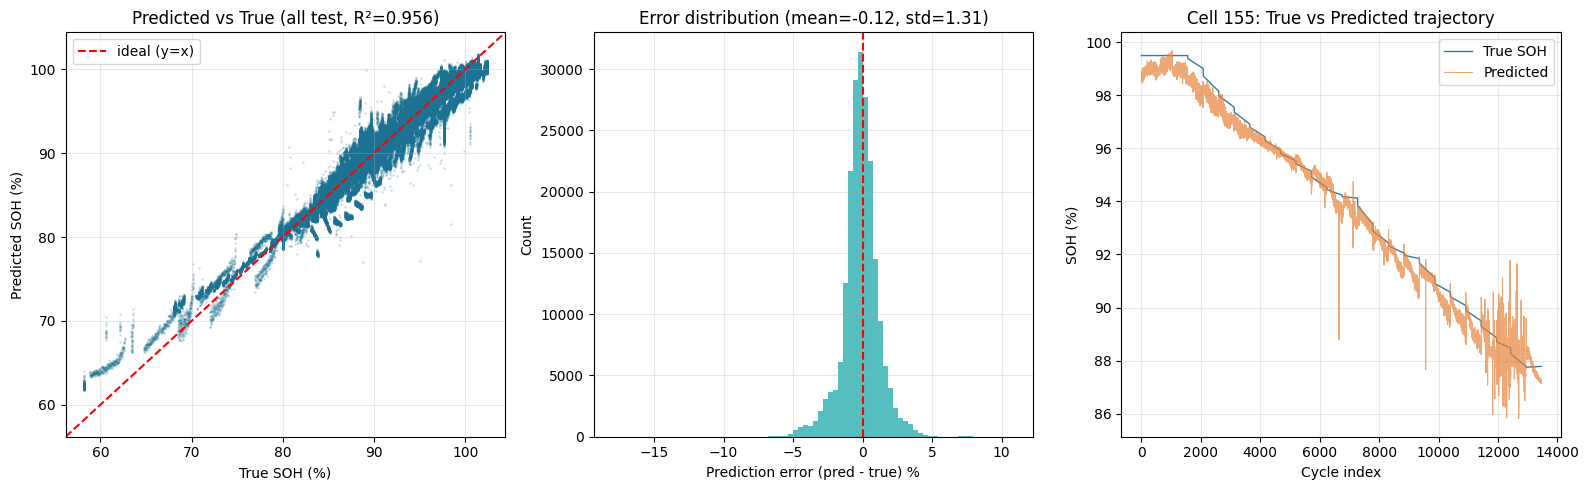

saved prediction_visual.png


In [11]:
import numpy as np, pandas as pd, glob, os
import matplotlib.pyplot as plt

# 收集所有测试块的预测和真实(preds已在内存)
all_p,all_t,all_bid=[],[],[]
for bid,p in preds.items():
    y=pd.read_csv(f'y_test_secret/y_{bid}.csv')['SOH'].values
    all_p.append(p); all_t.append(y); all_bid+=[bid]*len(y)
all_p=np.concatenate(all_p); all_t=np.concatenate(all_t)

fig=plt.figure(figsize=(16,5))

# ===== 图1:预测 vs 真实 散点(全体)=====
ax1=fig.add_subplot(1,3,1)
ax1.scatter(all_t,all_p,s=1,alpha=0.15,color='#1C7293')
lim=[all_t.min()-2,all_t.max()+2]
ax1.plot(lim,lim,'r--',lw=1.5,label='ideal (y=x)')
ax1.set_xlabel('True SOH (%)'); ax1.set_ylabel('Predicted SOH (%)')
ax1.set_title(f'Predicted vs True (all test, R²=0.956)'); ax1.legend()
ax1.set_xlim(lim); ax1.set_ylim(lim); ax1.grid(alpha=0.3)

# ===== 图2:误差分布直方图 =====
ax2=fig.add_subplot(1,3,2)
err=all_p-all_t
ax2.hist(err,bins=80,color='#0FA3A3',alpha=0.7)
ax2.axvline(0,color='r',ls='--',lw=1.5)
ax2.set_xlabel('Prediction error (pred - true) %'); ax2.set_ylabel('Count')
ax2.set_title(f'Error distribution (mean={err.mean():.2f}, std={err.std():.2f})')
ax2.grid(alpha=0.3)

# ===== 图3:挑一块表现好的,画SOH曲线 =====
ax3=fig.add_subplot(1,3,3)
bid='155'   # 之前R²=0.98的好块,可换
y=pd.read_csv(f'y_test_secret/y_{bid}.csv')['SOH'].values
p=preds[bid]
x=np.arange(len(y))
ax3.plot(x,y,color='#065A82',lw=1,label='True SOH',alpha=0.8)
ax3.plot(x,p,color='#E8833A',lw=0.8,label='Predicted',alpha=0.7)
ax3.set_xlabel('Cycle index'); ax3.set_ylabel('SOH (%)')
ax3.set_title(f'Cell {bid}: True vs Predicted trajectory')
ax3.legend(); ax3.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_visual.png',dpi=140)
plt.show()
print("saved prediction_visual.png")